<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_WEEK9_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 5.2 합성곱 신경맛 맛보기

**fashion_mnist 데이터셋**

토치비전에 내장된 예제 데이터. 운동화, 셔츠, 샌들 같은 작은 이미지의 모음이며, 기본 MNIST 데이터셋처럼 열 가지로 분류될 수 있는 28*28 픽셀의 이미지 7만 개로 구성되어 있음.

**GPU 사용**

device = torch.device( "cuda:0" if torch.cuda.is_available() else "cpu")
model=Net( )
mode.to(device)

device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
model = Net()
if torch.cuda.device_count() > 1:
model = nn.DataParallel(net)
model.to(device)

**nn.DataParallel을 사용할 경우  배치 크기가 알아서 각 GPU로 분배됨**

In [1]:
# 5-1 라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as plt
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transfroms
from torch.utils.data import Dataset,DataLoader

1. torchvision.datasets의 주요 파라미터
- FashionMNIST를 내려받을 위치를 지정.
- download: True로 변경할 시 위 파라미터의 위치에 해당 데이터셋이 있는지 확인한 후 내려받음
- transform: 이미지를 텐서(0~1)로 변경


In [2]:
# 5-2 CPU 혹은 GPU 장치 확인
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
train_dataset=torchvision.datasets.FashionMNIST(root="./data/FashionMNIST",download=True,
                                             transform=transfroms.Compose([transfroms.ToTensor()]))
test_dataset=torchvision.datasets.FashionMNIST(root="./data/FashionMNIST",download=True,
                                               train=False,transform=transfroms.Compose([transfroms.ToTensor()]))

In [6]:
# 코드 5-4 fasion_mnist 데이터를 데이터로더에 전달
train_loader=DataLoader(train_dataset,batch_size=100)
test_loader=DataLoader(test_dataset,batch_size=100)

1. torch.utils.data.Downloader()를 사용하여 원하는 크기의 배치 단위로 데이터를 불러오거나, 순서가 무작위로 섞이도록 할 수 있음.
- train_dataset: 데이터를 불러올 데이터셋 지정
- batch_size: 데이터를 배치로 묶어 줌.

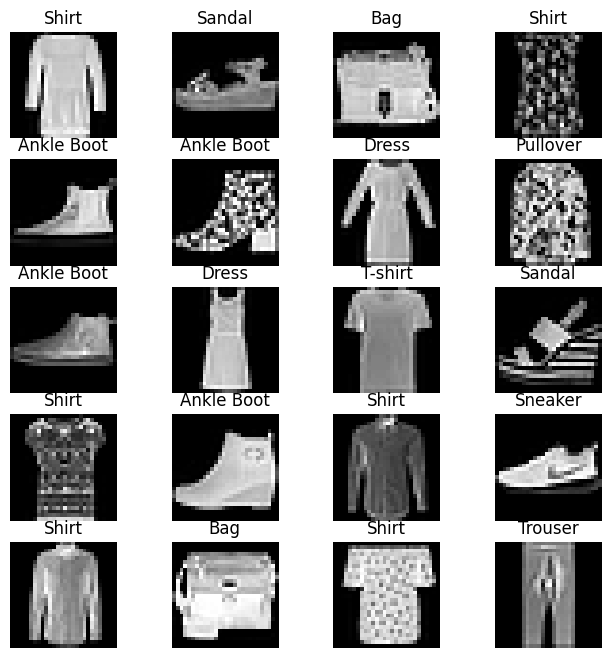

In [8]:
# 코드 5-5 분류에 사용될 클래스 정의
import matplotlib.pyplot as plt # Re-import matplotlib.pyplot to ensure 'plt' refers to the correct module
labels_map={0:'T-shirt',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',5:'Sandal',6:'Shirt',7:'Sneaker',8:'Bag',9:'Ankle Boot'}

fig=plt.figure(figsize=(8,8));
columns=4;
rows=5;
for i in range(1,columns*rows+1):
  img_xy=np.random.randint(len(train_dataset));
  img=train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows,columns,i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img,cmap='gray')
plt.show()

1

np.random: 무작위로 데이터를 생성할 때 사용

np.random.randint(): 이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용.

2. train_dataset을 이용한 3차원 배열 생성.

In [10]:
import torch.nn as nn
# 코드 5-6 심층 신경망 모델 생성
class FasionDNN(nn.Module):
  def __init__(self):
    super(FasionDNN,self).__init__()
    self.fc1=nn.Linear(in_features=784,out_features=256)
    self.drop=nn.Dropout(0.25)
    self.fc2=nn.Linear(in_features=256,out_features=128)
    self.fc3=nn.Linear(in_features=128,out_features=10)

  def forward(self,input_data):
    out=input_data.view(-1,784)
    out=F.relu(self.fc1(out))
    out=self.drop(out)
    out=F.relu(self.fc2(out))
    out=self.fc3(out)
    return out

1. 클래스 형태의 모델은 항상 torch.nn.Module을 상속받음. __init__()은 객체가 갖는 속성 값을 초기화하는 역할.

**객체**

객체 지향 프로그래밍은 프로그래밍에서 필요한 데이터를 추상화하여 속성, 행동, 동작, 특징 등을 객체로 만들고 객체들이 서로 유기적으로 동작하도록 하는 프로그래밍 방법.
- 객체: 메모리를 할당받아 프로그램에서 사용되는 모든 데이터. 변수, 함수 등
- 객체명=클래스명()

**클래스와 함수**

하나의 특정 작업을 수행하기 위해 독립적으로 설계된 프로그램 코드.
- 클래스: 함수뿐 아니라 관련된 변수까지도 한꺼번에 묶어서 관리하고 재사용할 수 있게 해주는 것.

2. nn: 딥러닝 모델 구성에 필요한 모듈이 모여 있는 패키지. / linear: 단순 선형 회귀 모델을 만들 때 사용.
- in_features: 입력 크기
- out_features: 출력 크기

3. torch.nn.Dropout(p): p의 비율로 텐서의 값이 0, 0이 되지 않은 값들은 기존 값에 1/(1-p)만큼 곱해져 커짐.

4. forward() 모델이 학습 데이터를 입력받아 순전파 학습을 진행시킴.

5. view: 넘파이의 reshape 역할. 텐서의 크기 변경.

6. 활성화 함수 지정 1) F.relu(), 2) nn.ReLU()

**nn.xx와 nn.functional.xx의 사용 방법 비교**

nn.xx
- 형태: nn.Conv2d, nn.Module 클래스를 상속받아 사용.
- 호출방법: 하이퍼파라미터 전달 > 함수 호출을 통해 데이터 전달
- 위치: nn.Sequential 내에 위치
- 파라미터: 새로 정의할 필요 없음

nn.functional.xx
- 형태: nn.functional.conv2d
- 호출방법: 함수를 호출할 때 하이퍼파라미터, 데이터 전달
- 위치: nn.Sequential에 위치할 수 없음.
- 파라미터: 가중치를 수동으로 전달해야 할 때마다 자체 가중치 정의

In [13]:
# 5-7 심층 신경망에서 필요한 파라미터 정의
import torch.optim as optim
learning_rate=0.001;
model=FasionDNN();
model.to(device)

criterion=nn.CrossEntropyLoss();
optimizer=optim.Adam(model.parameters(),lr=learning_rate);
print(model)

FasionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


1. 옵티마이저를 위한 경사하강법으로 Adam 사용. Ir은 0.001 사용.


In [15]:
# 코드 5-8 심층 신경망을 이용한 모델 학습
num_epochs=5
count=0

loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
  for images,labels in train_loader:
      images,labels=images.to(device),labels.to(device)

      train=Variable(images.view(100,1,28,28))
      labels=Variable(labels)

      outputs=model(train)
      loss=criterion(outputs,labels)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      count+=1

      if not (count % 50):
        total=0
        correct=0
        for images,labels in test_loader:
          images,labels=images.to(device),labels.to(device)
          labels_list.append(labels)
          test=Variable(images.view(100,1,28,28))
          outputs=model(test)
          predictions=torch.max(outputs,1)[1].to(device)
          predictions_list.append(predictions)
          correct+=(predictions==labels).sum()
          total+=len(labels)

        accuracy=correct*100/total
        loss_list.append(loss.data)
        iteration_list.append(count)
        accuracy_list.append(accuracy)

if not (count%500):
  print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count,loss.data,accuracy))

Iteration: 3000, Loss: 0.29122087359428406, Accuracy: 86.61000061035156%


2. 합성곱층: 합성곱 연산을 통해 이미지의 특징 추출.
- out_channels: 출력 채널의 수
- kernel_size: 커널 크기, 필터. 이미지 특징을 찾아내기 위한 공용 파라미터. CNN에서 학습 대상은 필터 파라미터가 됨. 커널은 입력 데이터를 스트라이드 간격으로 순회하며 합성곱 계산.
- padding: 패딩 크기. 출력 크기를 조정하기 위해 입력 데이터 주위에 0을 채움.

3. BatchNorm2d: 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용하여 정규화하는 것. 정규화를 통해 분포를 가우시안 형태로 만듦.

4. MaxPool2d: 이미지의 크기를 축소시키는 용도로 사용. / 풀링 계층: 합성곱층의 출력 데이터를 입력으로 받아 출력 데이터의 크기를 줄이거나 특정 데이터를 강조하는 용도로 사용(최대 풀링, 최소 풀링)
- kernel_size
- stride: 입력 데이터에 커널을 적용할 때 이동할 간격을 의미. 값이 커지면 출력 크기 감소.

**Conv2d 계층에서의 출력 크기 구하는 공식**

출력 크기=(W-F+2P)/S+1
- W: 입력 데이터의 크기
- F: 커널 크기
- P: 패딩 크기
- S: 스트라이드

**MaxPool2d 계층에서의 출력 크기 구하는 공식**

출력 크기=IF/F
- IF: 입력 필터의 크기
- F: 커널 크기

In [16]:
# 5-9 합성곱 네트워크 생성
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1=nn.Sequential(
        nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.layer2=nn.Sequential(
        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1=nn.Linear(in_features=64*6*6,out_features=600)
    self.drop=nn.Dropout2d(0.25)
    self.fc2=nn.Linear(in_features=600,out_features=120)
    self.fc3=nn.Linear(in_features=120,out_features=10)

  def forward(self,x):
    out=self.layer1(x)
    out=self.layer2(out)
    out=out.view(out.size(0),-1)
    out=self.fc1(out)
    out=self.drop(out)
    out=self.fc2(out)
    out=self.fc3(out)
    return out

In [17]:
# 코드 5-10 합성곱 네트워크를 위한 파라미터 정의
learning_rate=0.001;
model=FashionCNN();
model.to(device)

criterion=nn.CrossEntropyLoss();
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [18]:
# 코드 5-11 모델 학습 및 성능 평가
num_epochs=5
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)

    train=Variable(images.view(100,1,28,28))
    labels=Variable(labels)

    outputs=model(train)
    loss=criterion(outputs,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count+=1

    if not (count%50):
      total=0
      correct=0
      for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        labels_list.append(labels)
        test=Variable(images.view(100,1,28,28))
        outputs=model(test)
        predictions=torch.max(outputs,1)[1].to(device)
        predictions_list.append(predictions)
        correct+=(predictions==labels).sum()
        total+=len(labels)

      accuracy=correct*100/total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count%500):
      print("Iteration:{},Loss:{},Accuracy:{}%".format(count,loss.data,accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration:500,Loss:0.49727606773376465,Accuracy:86.95999908447266%
Iteration:1000,Loss:0.35602688789367676,Accuracy:88.68999481201172%
Iteration:1500,Loss:0.35133275389671326,Accuracy:87.6199951171875%
Iteration:2000,Loss:0.23987150192260742,Accuracy:89.41999816894531%
Iteration:2500,Loss:0.21071109175682068,Accuracy:89.68000030517578%
Iteration:3000,Loss:0.15703918039798737,Accuracy:90.0%
